# 02 — Analisis Review Pelanggan
Distribusi rating, korelasi rating vs keterlambatan pengiriman.

Distribusi rating pelanggan

Pertanyaan: mayoritas pelanggan puas atau tidak?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load data
df       = pd.read_csv('../output/orders_clean.csv',
                       parse_dates=['order_purchase_timestamp',
                                    'order_delivered_customer_date',
                                    'order_estimated_delivery_date'])
reviews  = pd.read_csv('../data/olist_order_reviews_dataset.csv')

# Gabungkan dengan data order
df_rev = df.merge(reviews[['order_id','review_score',
                            'review_comment_message']],
                  on='order_id', how='inner')

print("Total order dengan review:", len(df_rev))
print(df_rev['review_score'].value_counts().sort_index())

Total order dengan review: 110013
review_score
1    12575
2     3700
3     9242
4    21184
5    63312
Name: count, dtype: int64


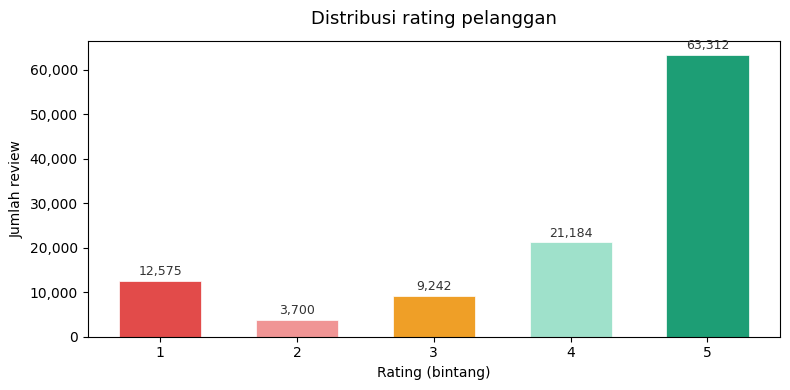

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#E24B4A','#F09595','#EF9F27','#9FE1CB','#1D9E75']
counts = df_rev['review_score'].value_counts().sort_index()

bars = ax.bar(counts.index, counts.values,
              color=colors, width=0.6, edgecolor='white', linewidth=0.5)

# Label angka di atas tiap bar
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(counts.values)*0.01,
            f'{val:,}',
            ha='center', va='bottom',
            fontsize=9,
            color='#333333')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_title('Distribusi rating pelanggan', fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Rating (bintang)')
ax.set_ylabel('Jumlah review')
ax.set_xticks([1,2,3,4,5])

plt.tight_layout()
plt.savefig('../output/05-distribusi-rating.png', dpi=150)
plt.show()

 ~76% pelanggan memberi rating 4 atau 5 — tanda kepuasan yang kuat. Tapi ada 11.424 rating bintang 1 yang menarik untuk ditelusuri lebih dalam. Apa penyebabnya?

Hitung keterlambatan pengiriman

Pertanyaan: apakah telat kirim bikin rating turun?

In [4]:
# Hitung selisih hari: aktual vs estimasi
df_rev['delay_days'] = (
    df_rev['order_delivered_customer_date'] -
    df_rev['order_estimated_delivery_date']
).dt.days

# Angka positif = telat, negatif = lebih cepat dari estimasi
print(df_rev['delay_days'].describe().round(1))
print(f"\nOrder yang telat  : {(df_rev['delay_days'] > 0).sum():,}")
print(f"Order tepat/lebih cepat: {(df_rev['delay_days'] <= 0).sum():,}")

count    110005.0
mean        -12.1
std          10.1
min        -147.0
25%         -17.0
50%         -13.0
75%          -7.0
max         188.0
Name: delay_days, dtype: float64

Order yang telat  : 7,112
Order tepat/lebih cepat: 102,893


In [5]:
def kategorikan_delay(days):
    if days <= 0:
        return '1. Tepat/lebih cepat'
    elif days <= 7:
        return '2. Telat 1–7 hari'
    elif days <= 14:
        return '3. Telat 8–14 hari'
    else:
        return '4. Telat >14 hari'

df_rev['delay_category'] = df_rev['delay_days'].apply(kategorikan_delay)
print(df_rev['delay_category'].value_counts())

delay_category
1. Tepat/lebih cepat    102893
2. Telat 1–7 hari         4044
3. Telat 8–14 hari        1587
4. Telat >14 hari         1489
Name: count, dtype: int64


Rating rata-rata per kategori keterlambatan

Pertanyaan: seberapa besar dampak keterlambatan ke rating?

C:\Users\asus\AppData\Local\Temp\ipykernel_21980\2179951008.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(


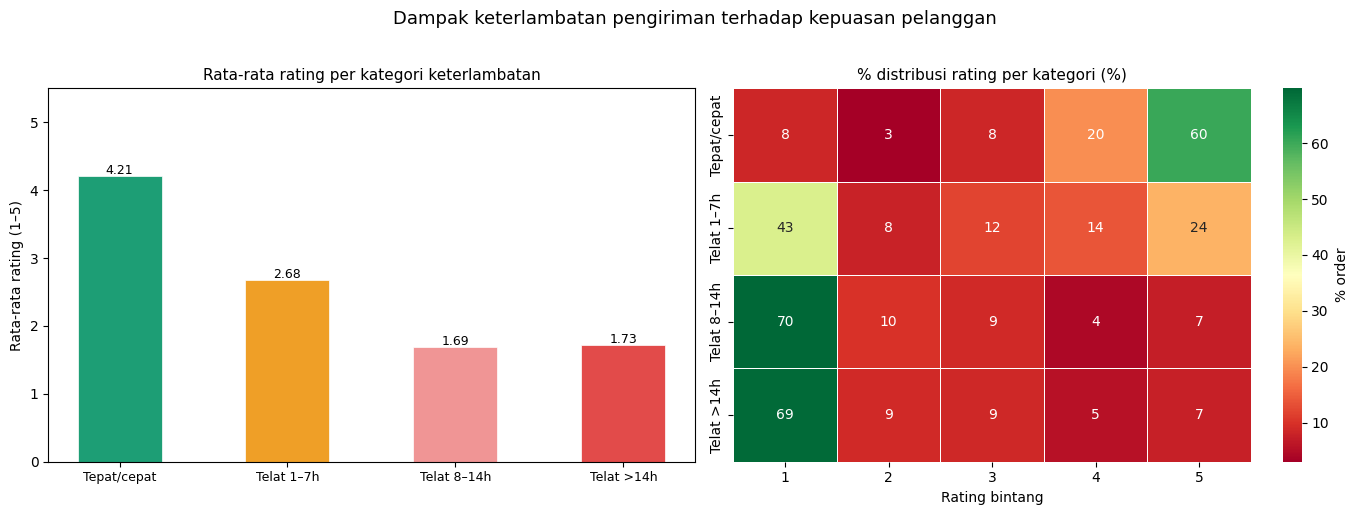


Rata-rata rating per kategori:
      delay_category  review_score
1. Tepat/lebih cepat      4.207410
   2. Telat 1–7 hari      2.678783
  3. Telat 8–14 hari      1.689351
   4. Telat >14 hari      1.725991


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Grafik kiri: rata-rata rating per kategori delay ──────────
avg_rating = (df_rev.groupby('delay_category')['review_score']
              .mean().reset_index()
              .sort_values('delay_category'))

colors_delay = ['#1D9E75','#EF9F27','#F09595','#E24B4A']
bars = axes[0].bar(avg_rating['delay_category'],
                   avg_rating['review_score'],
                   color=colors_delay, width=0.5,
                   edgecolor='white', linewidth=0.5)

# Label nilai di atas bar
for bar, val in zip(bars, avg_rating['review_score']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.03,
                 f'{val:.2f}', ha='center', fontsize=9)

axes[0].set_ylim(0, 5.5)
axes[0].set_title('Rata-rata rating per kategori keterlambatan',
                  fontsize=11, fontweight='500')
axes[0].set_ylabel('Rata-rata rating (1–5)')
axes[0].set_xticklabels(
    ['Tepat/cepat','Telat 1–7h','Telat 8–14h','Telat >14h'],
    fontsize=9)

# ── Grafik kanan: distribusi rating per kategori (heatmap) ────
pivot = (df_rev.groupby(['delay_category','review_score'])
         .size().unstack(fill_value=0))
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

sns.heatmap(pivot_pct, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': '% order'},
            yticklabels=['Tepat/cepat','Telat 1–7h',
                         'Telat 8–14h','Telat >14h'])
axes[1].set_title('% distribusi rating per kategori (%)',
                  fontsize=11, fontweight='500')
axes[1].set_xlabel('Rating bintang')
axes[1].set_ylabel('')

plt.suptitle('Dampak keterlambatan pengiriman terhadap kepuasan pelanggan',
             fontsize=13, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig('../output/06-rating-vs-delay.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan insight
print("\nRata-rata rating per kategori:")
print(avg_rating.to_string(index=False))